# Environment

In [1]:
library(dplyr)
library(DBI)
library(RSQLite)
library(sf)
library(spdep)
library(sp)
library(tidyverse)
library(grf)
library(spatialRF)
library(arrow)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'RSQLite' was built under R version 4.5.2"
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts

# Loading data

In [3]:
repo_path <- dirname(file.path(getwd()))
list_of_columns <- c(
  'gdf_rho_0_251_nspred',
 'gdf_rho_0_301_nspred',
 'gdf_rho_0_351_nspred',
 'gdf_rho_0_401_nspred',
 'gdf_rho_0_451_nspred',
 'gdf_rho_0_501_nspred',
 'gdf_rho_0_551_nspred',
 'gdf_rho_0_601_nspred',
 'gdf_rho_0_651_nspred',
 'gdf_rho_0_701_nspred',
 'gdf_rho_0_751_nspred',
 'gdf_rho_0_801_nspred',
 'gdf_rho_0_851_nspred',
 'gdf_rho_0_901_nspred',
 'gdf_rho_0_951_nspred'
)

con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data_nsp.sqlite")
)

dict_geom_sf <- setNames(
  lapply(list_of_columns, function(layer) {

    geom_df <- dbReadTable(con, layer)

    sf_obj <- st_as_sf(
      geom_df,
      coords = c("x", "y"),   # <- KLUCZOWE
      crs = 3857,             # ustaw CRS od razu
      remove = FALSE
    )

    geom_df2 <- geom_df[, !(names(geom_df) %in% c("x", "y"))]

    list(
      sf = sf_obj,
      df = geom_df2
    )
  }),
  list_of_columns
)

dbDisconnect(con)

# Distance matrix

In [4]:
centroids <- sf::st_centroid(dict_geom_sf$gdf_rho_0_251_nspred$sf)

distance_matrix <- units::drop_units(
  as.matrix(sf::st_distance(centroids))
)

# Preparing and saving spatial predictors

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            15
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5466936
  - R squared (cor(obs, pred)^2):     0.9502579
  - Pseudo R squared (cor(obs, pred)):0.9748117
  - RMSE (oob):                       0.9645097
  - RMSE:                             0.4164
  - Normalized RMSE:                  0.2327276

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.19 │  -

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            12
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5372731
  - R squared (cor(obs, pred)^2):     0.9444887
  - Pseudo R squared (cor(obs, pred)):0.9718481
  - RMSE (oob):                       0.9482782
  - RMSE:                             0.4092
  - Normalized RMSE:                  0.2246999

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.20 │  

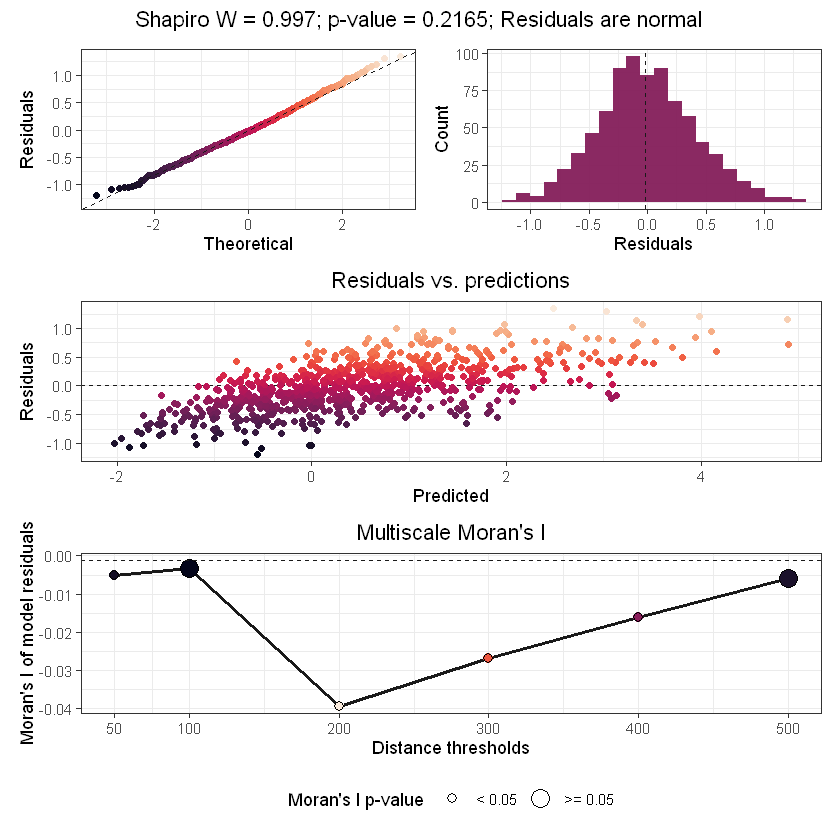

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            16
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5811054
  - R squared (cor(obs, pred)^2):     0.9523708
  - Pseudo R squared (cor(obs, pred)):0.9758949
  - RMSE (oob):                       0.9952799
  - RMSE:                             0.4223
  - Normalized RMSE:                  0.2236226

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.41 │  -

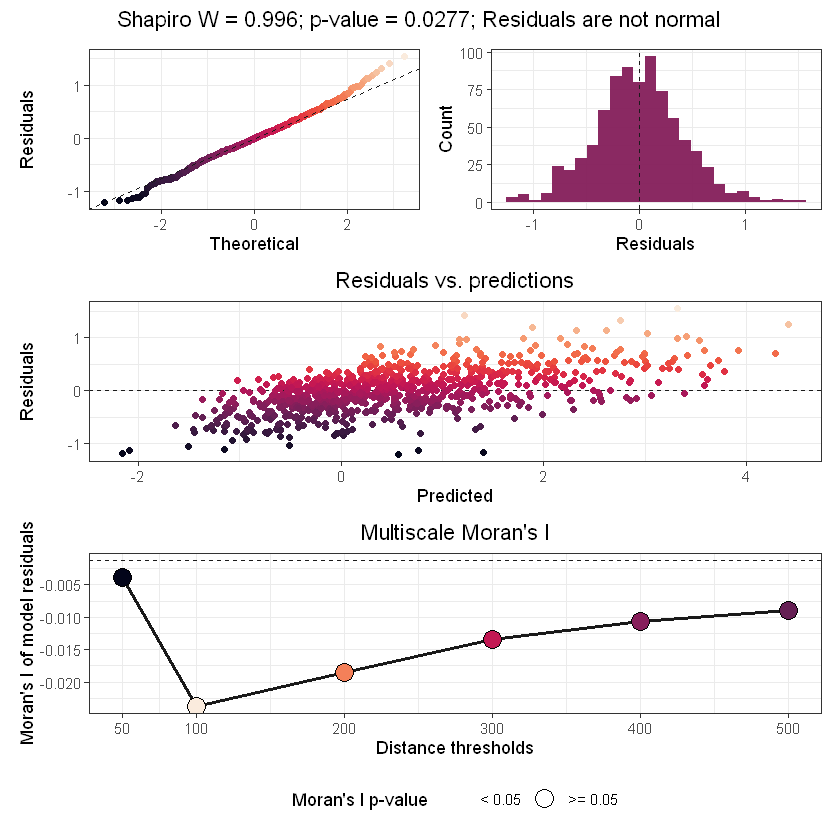

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            13
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5758825
  - R squared (cor(obs, pred)^2):     0.9501225
  - Pseudo R squared (cor(obs, pred)):0.9747423
  - RMSE (oob):                       0.9771339
  - RMSE:                             0.4225
  - Normalized RMSE:                  0.2175936

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.38 │  -

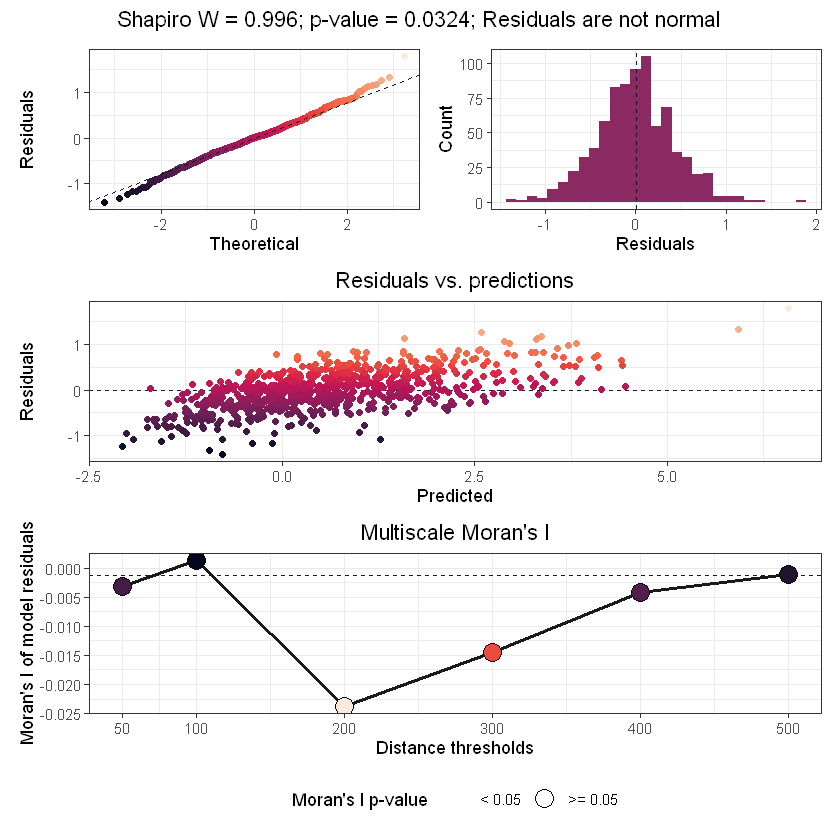

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            13
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.6140844
  - R squared (cor(obs, pred)^2):     0.9542712
  - Pseudo R squared (cor(obs, pred)):0.9768681
  - RMSE (oob):                       0.9898356
  - RMSE:                             0.4293
  - Normalized RMSE:                  0.2142837

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.40 │  

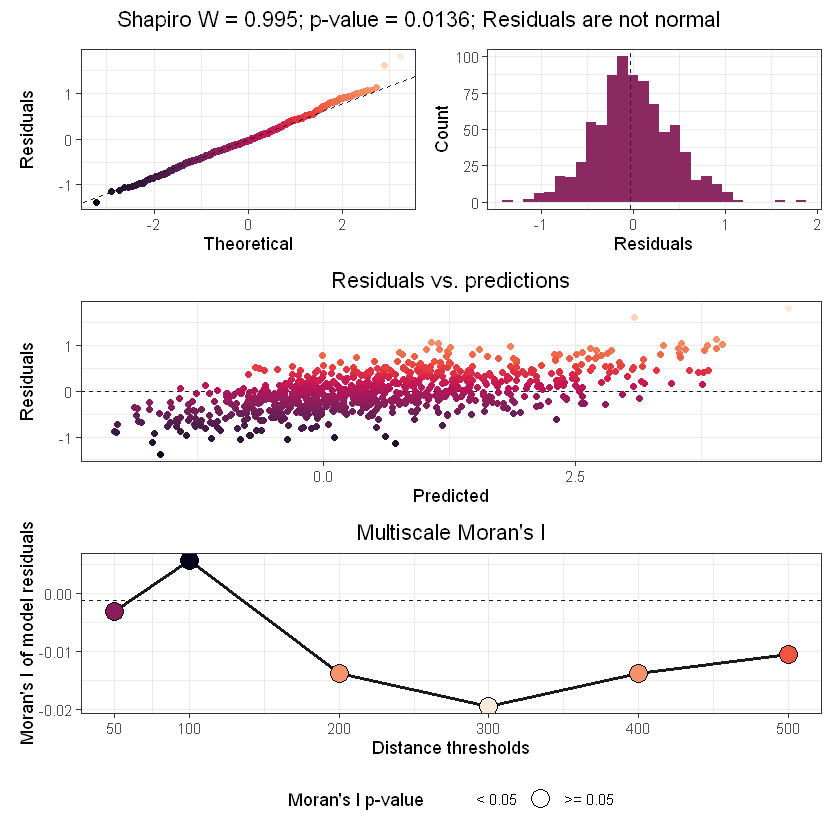

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            12
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.6500134
  - R squared (cor(obs, pred)^2):     0.956292
  - Pseudo R squared (cor(obs, pred)):0.9779019
  - RMSE (oob):                       1.005962
  - RMSE:                             0.4369
  - Normalized RMSE:                  0.2139791

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.49 │  -0

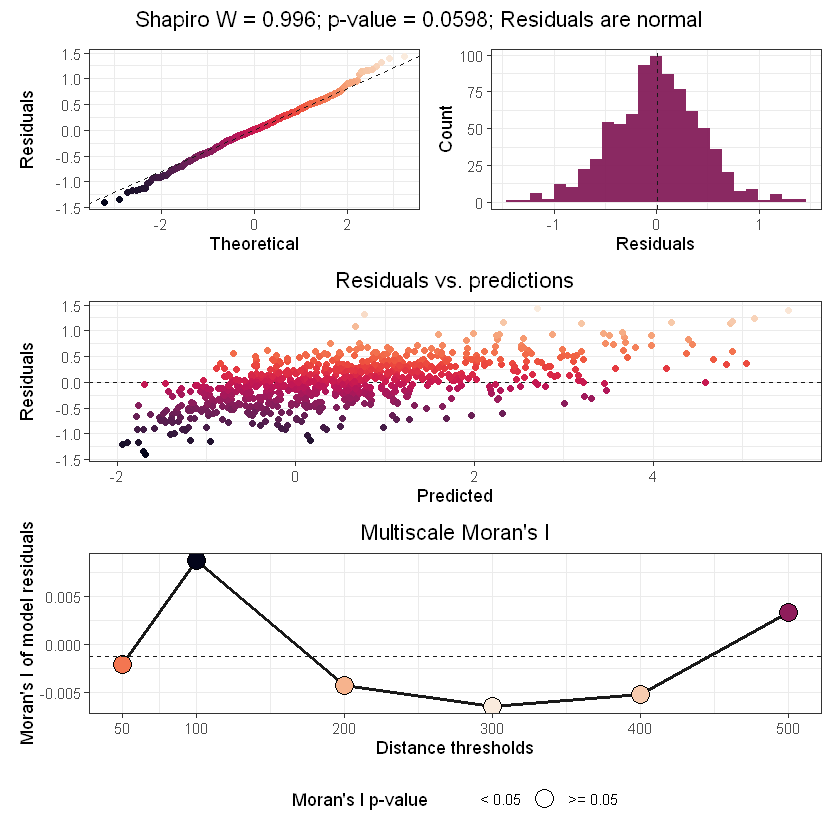

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            17
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5925358
  - R squared (cor(obs, pred)^2):     0.9555345
  - Pseudo R squared (cor(obs, pred)):0.9775144
  - RMSE (oob):                       1.032707
  - RMSE:                             0.4362
  - Normalized RMSE:                  0.2451245

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.43 │  -

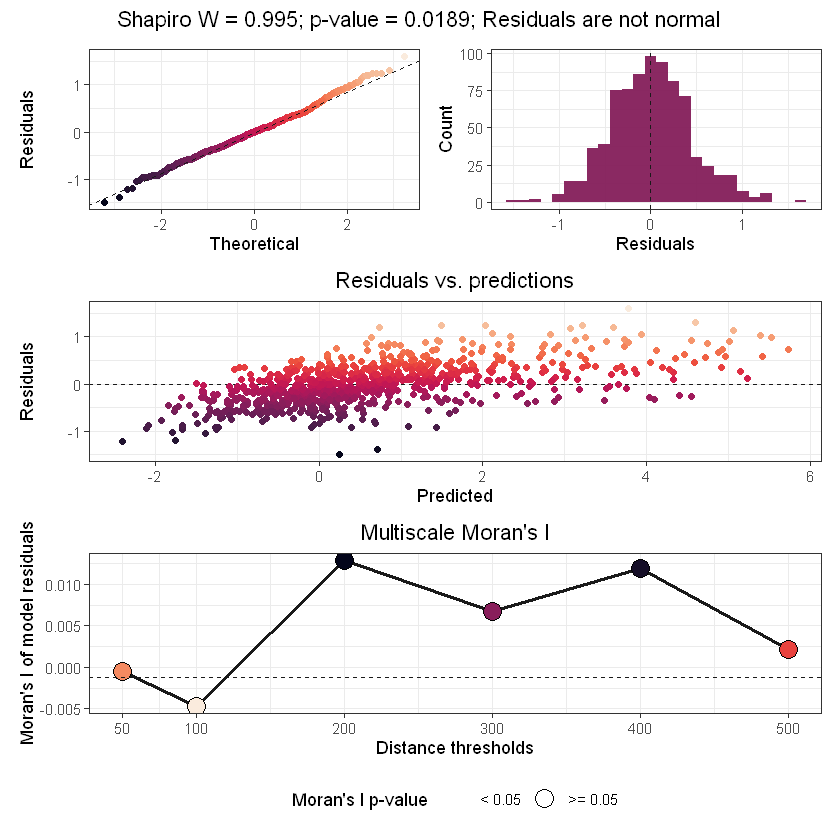

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            23
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.6625656
  - R squared (cor(obs, pred)^2):     0.9630589
  - Pseudo R squared (cor(obs, pred)):0.9813557
  - RMSE (oob):                       1.023471
  - RMSE:                             0.4353
  - Normalized RMSE:                  0.2329528

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.51 │  -

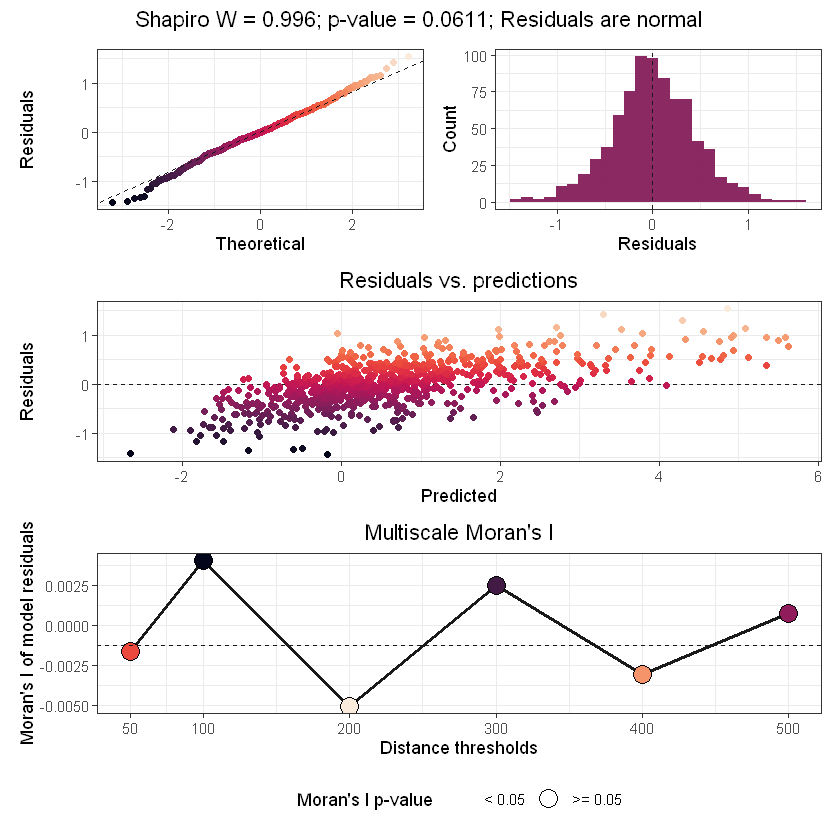

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            21
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.6917672
  - R squared (cor(obs, pred)^2):     0.960912
  - Pseudo R squared (cor(obs, pred)):0.9802612
  - RMSE (oob):                       1.008374
  - RMSE:                             0.4299
  - Normalized RMSE:                  0.2156509

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.15 │  -0

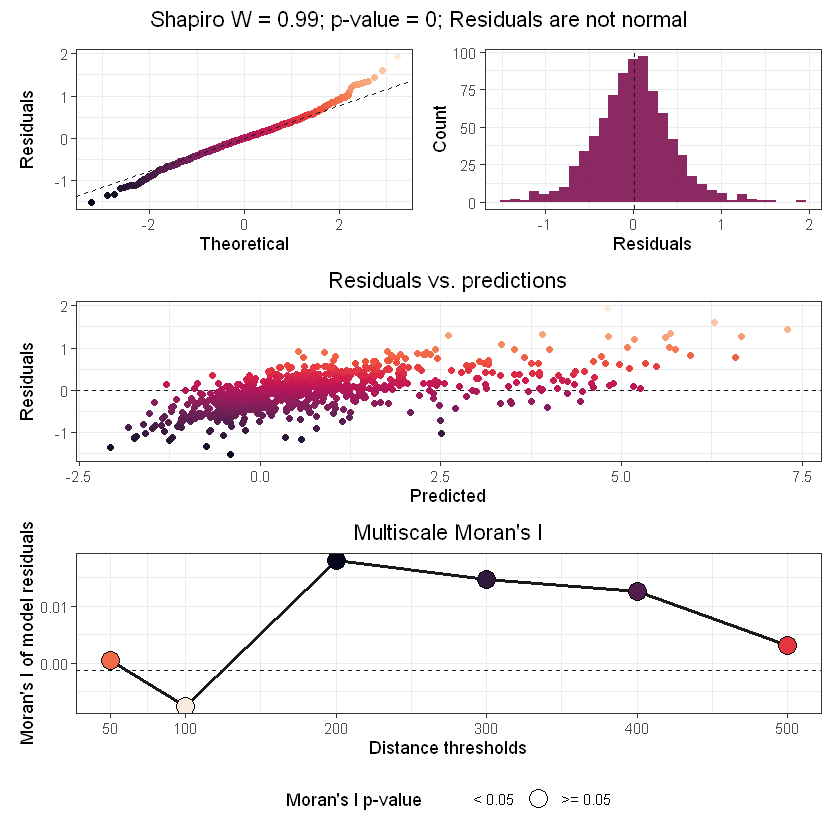

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            26
  - Mtry:                            5
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.7426057
  - R squared (cor(obs, pred)^2):     0.9697709
  - Pseudo R squared (cor(obs, pred)):0.9847694
  - RMSE (oob):                       1.046789
  - RMSE:                             0.4424
  - Normalized RMSE:                  0.2385013

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.44 │  -

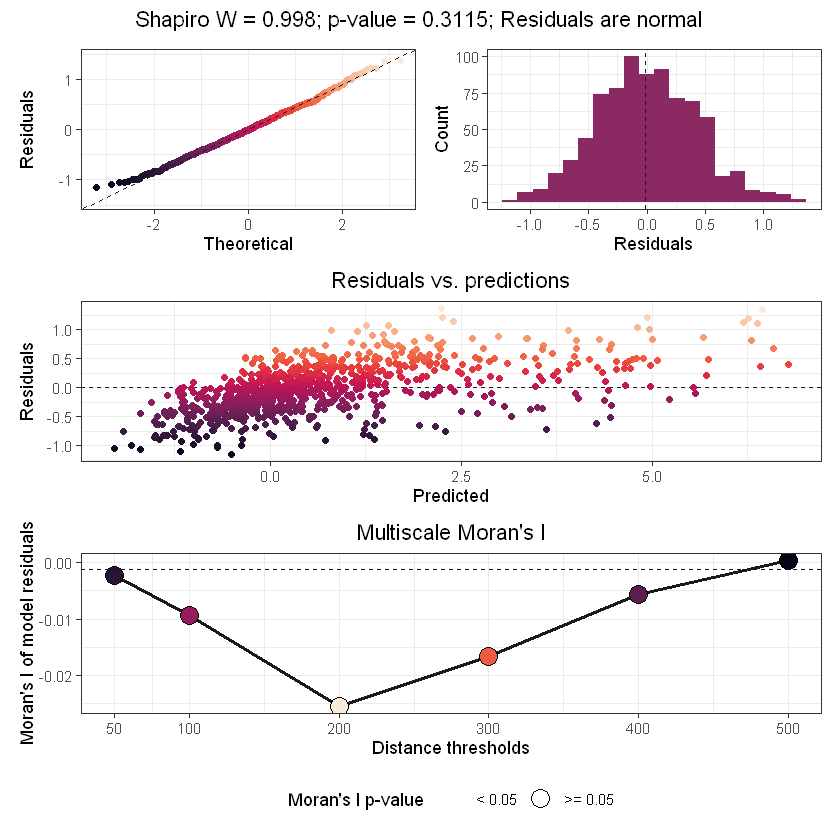

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            21
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.7293957
  - R squared (cor(obs, pred)^2):     0.9667837
  - Pseudo R squared (cor(obs, pred)):0.9832516
  - RMSE (oob):                       1.097294
  - RMSE:                             0.4679
  - Normalized RMSE:                  0.2454956

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.97 │  -

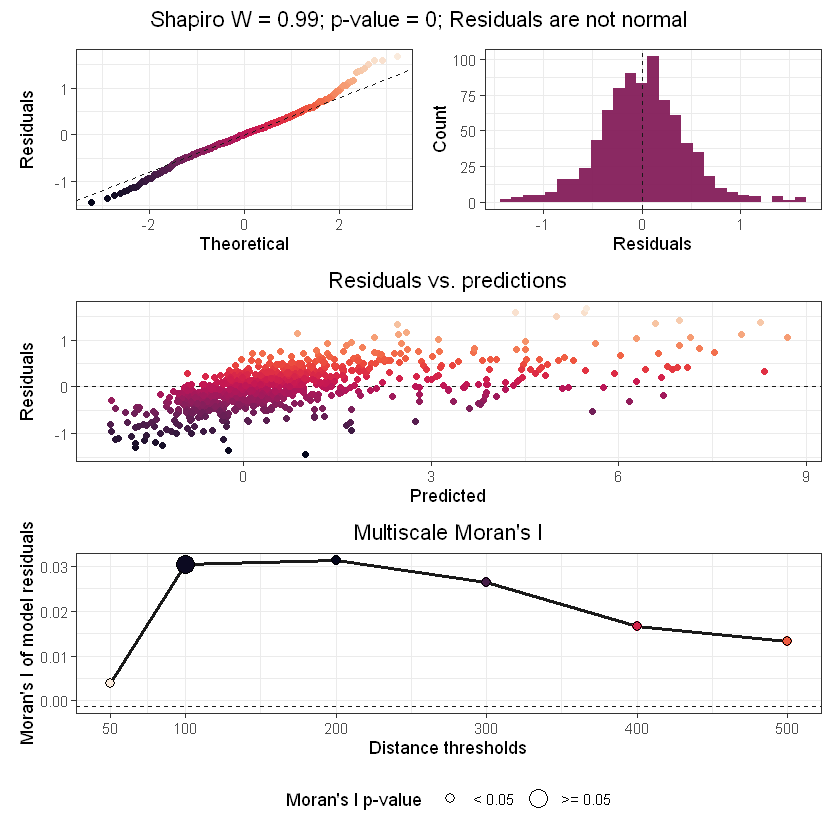

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            24
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.8008336
  - R squared (cor(obs, pred)^2):     0.972564
  - Pseudo R squared (cor(obs, pred)):0.9861866
  - RMSE (oob):                       1.108276
  - RMSE:                             0.4754
  - Normalized RMSE:                  0.203425

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.60 │  -0.

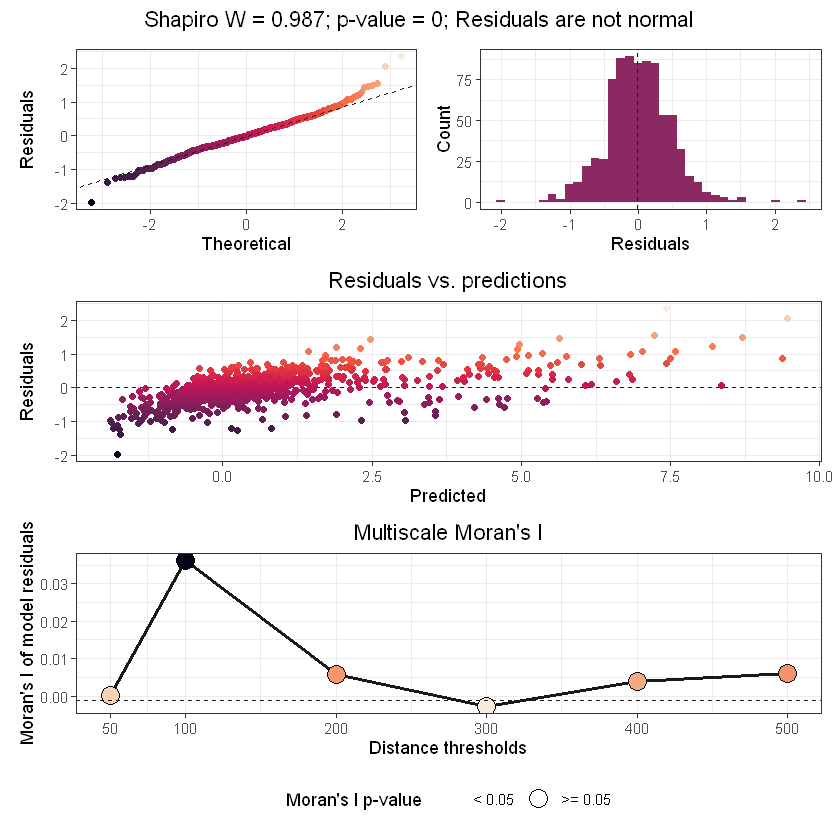

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            33
  - Mtry:                            5
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.845349
  - R squared (cor(obs, pred)^2):     0.980344
  - Pseudo R squared (cor(obs, pred)):0.9901232
  - RMSE (oob):                       1.230096
  - RMSE:                             0.5204
  - Normalized RMSE:                  0.2271752

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.69 │  -0.

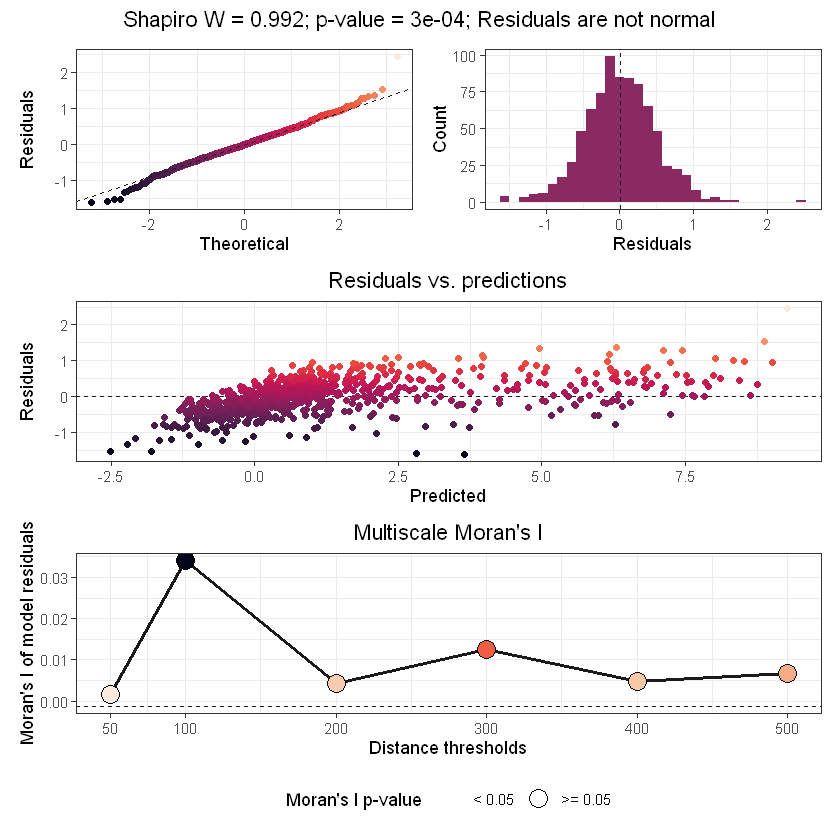

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            22
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.9029282
  - R squared (cor(obs, pred)^2):     0.986614
  - Pseudo R squared (cor(obs, pred)):0.9932845
  - RMSE (oob):                       1.192901
  - RMSE:                             0.5097
  - Normalized RMSE:                  0.2239693

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.59 │  -0

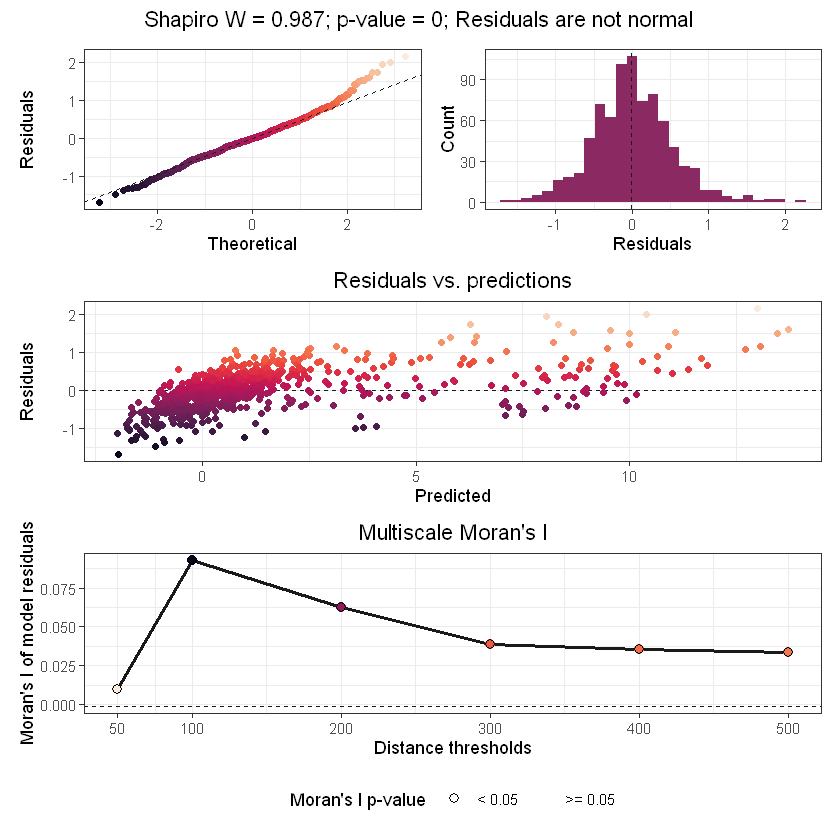

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               Y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            13
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.9242915
  - R squared (cor(obs, pred)^2):     0.9897849
  - Pseudo R squared (cor(obs, pred)):0.9948793
  - RMSE (oob):                       1.317672
  - RMSE:                             0.5717
  - Normalized RMSE:                  0.2473475

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.93 │  -

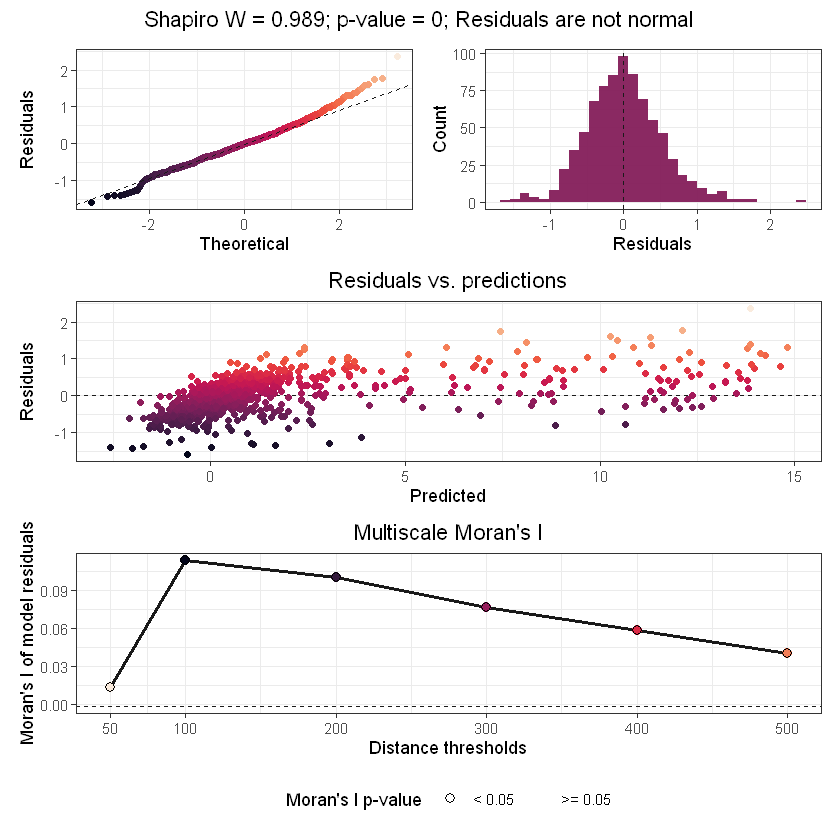

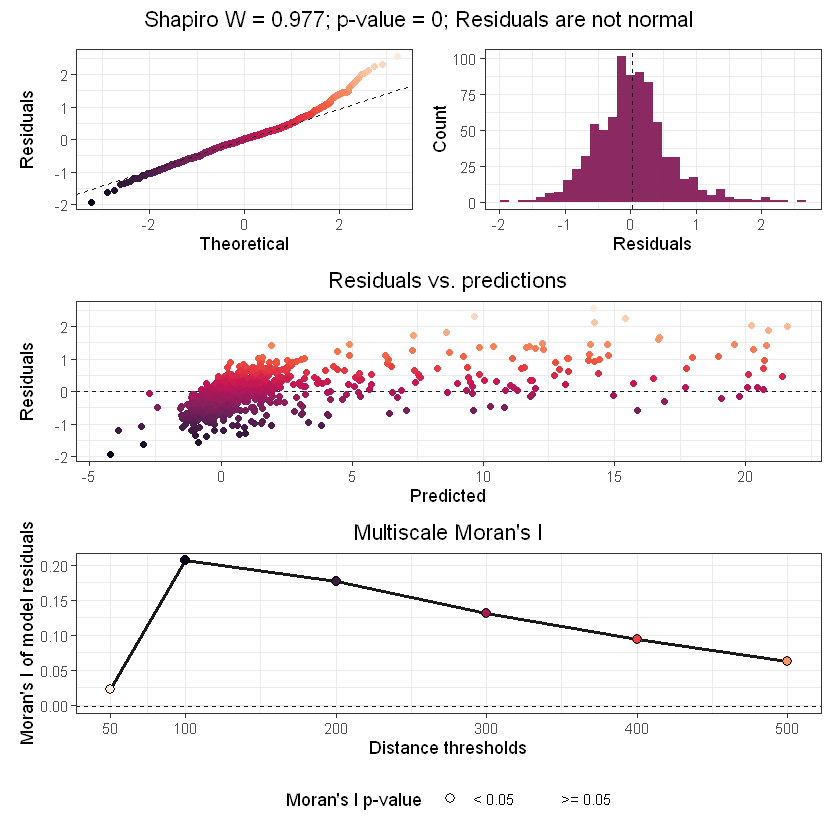

In [9]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data_nsp2.sqlite")
)

for (layer in list_of_columns) {

  df1 <- dict_geom_sf[[layer]]$df

  model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "Y_dep_var",
    predictor.variable.names = c('C1', 'C2'
                  #'t', 'odr_1','odr_2','odr_3','odr_4','odr_5'
                  ),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

  spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

  df3 <- cbind(df1, spatial_predictors_df)

  dbWriteTable(
    con,
    paste0(layer, "_sp"),
    df3,
    overwrite = TRUE
  )
}

dbDisconnect(con)